In [33]:
import sys
sys.path.insert(0, "..")

import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [34]:
from src.evaluation.metrics import build_predictions_report

In [35]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    palette = {"ML": "#1f77b4", "Statistical": "#ff7f0e", "Naive": "#2ca02c"}
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, hue_order=list(palette.keys()), order=df_sorted[y],
                dodge=False, palette=palette if hue else None, ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [36]:
!ls ../artifacts/models/

level_01_daily_total_sales_artifact.pkl
level_02_daily_state_sales_artifact.pkl
level_03_daily_cat_sales_artifact.pkl
level_04_daily_dept_sales_artifact.pkl
level_05_daily_state_cat_sales_artifact.pkl
level_06_daily_store_sales_artifact.pkl
level_07_daily_state_dept_sales_artifact.pkl
level_08_daily_store_cat_sales_artifact.pkl
level_09_daily_store_dept_sales_artifact.pkl
level_10_weekly_item__FOODS_1_sales_artifact.pkl
level_10_weekly_item__FOODS_2_sales_artifact.pkl
level_10_weekly_item__FOODS_3_sales_artifact.pkl
level_10_weekly_item__HOBBIES_1_sales_artifact.pkl
level_10_weekly_item__HOBBIES_2_sales_artifact.pkl
level_10_weekly_item__HOUSEHOLD_1_sales_artifact.pkl
level_10_weekly_item__HOUSEHOLD_2_sales_artifact.pkl
level_11_weekly_item_state__CA_FOODS_1_sales_artifact.pkl
level_11_weekly_item_state__CA_FOODS_2_sales_artifact.pkl
level_11_weekly_item_state__CA_FOODS_3_sales_artifact.pkl
level_11_weekly_item_state__CA_HOBBIES_1_sales_artifact.pkl
level_11_weekly_item_state__CA_HOBBI

In [37]:
ARTIFACT = "level_12_weekly_item_store__WI_3_HOBBIES_1_sales_artifact"

In [38]:
import joblib

from scripts.train_datasets import reconstruct_test_data

artifact_path = f"../artifacts/models/{ARTIFACT}.pkl"
artifact = joblib.load(artifact_path)

model = artifact["model"]
FEATURES = artifact["features"]
feature_importance = artifact["feature_importance"]
results_df = artifact["results_df"]

# El artifact es liviano (sin datos): X_test/y_test/train/test se reconstruyen acá
# desde data/datasets/ (make build-datasets), repitiendo el split de train_datasets.py.
X_test, y_test, artifact["train"], artifact["test"] = reconstruct_test_data(artifact)

2026-08-26 22:28:14.947 | INFO     | scripts.train_datasets:load_data:151 - level_12_weekly_item_store__WI_3_HOBBIES_1 | target=sales | 115,648 filas | 99 features (9 categóricas)
2026-08-26 22:28:14.967 | INFO     | src.data.split:log_summary:46 - Train : 2011-01-29 to 2016-03-26 (1,884 days, 112,320 rows)
2026-08-26 22:28:14.968 | INFO     | src.data.split:log_summary:47 - Valid : 2016-03-27 to 2016-04-23 (28 days, 1,664 rows)
2026-08-26 22:28:14.968 | INFO     | src.data.split:log_summary:48 - Test  : 2016-04-24 to 2016-05-21 (28 days, 1,664 rows)
2026-08-26 22:28:15.173 | INFO     | scripts.train_datasets:split_data:198 - Features: 99 (9 categóricas)


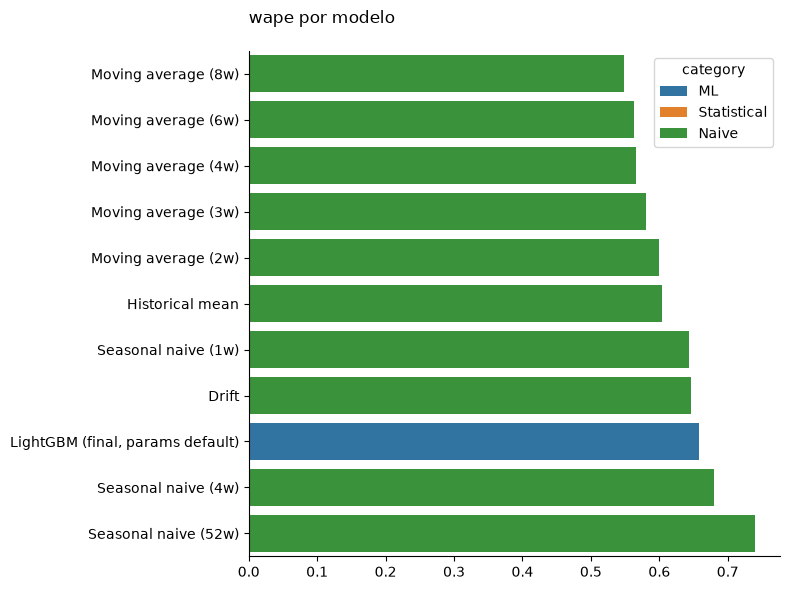

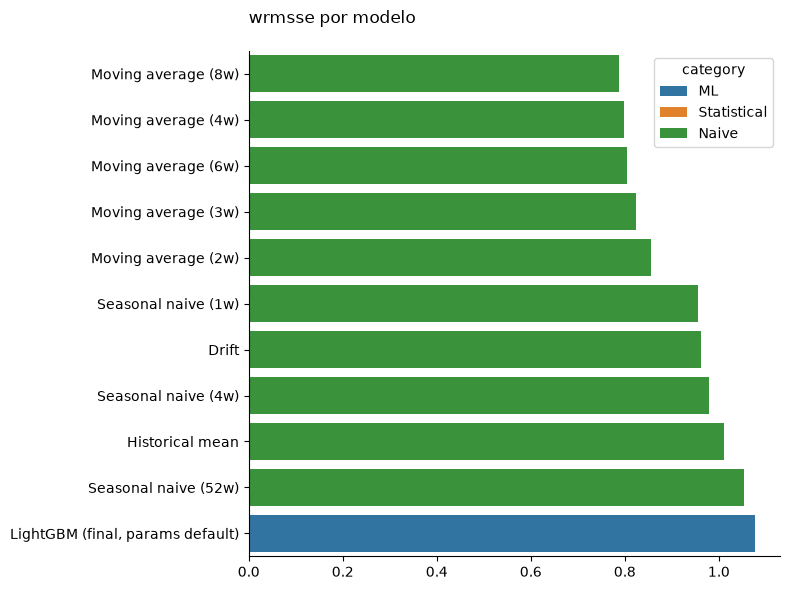

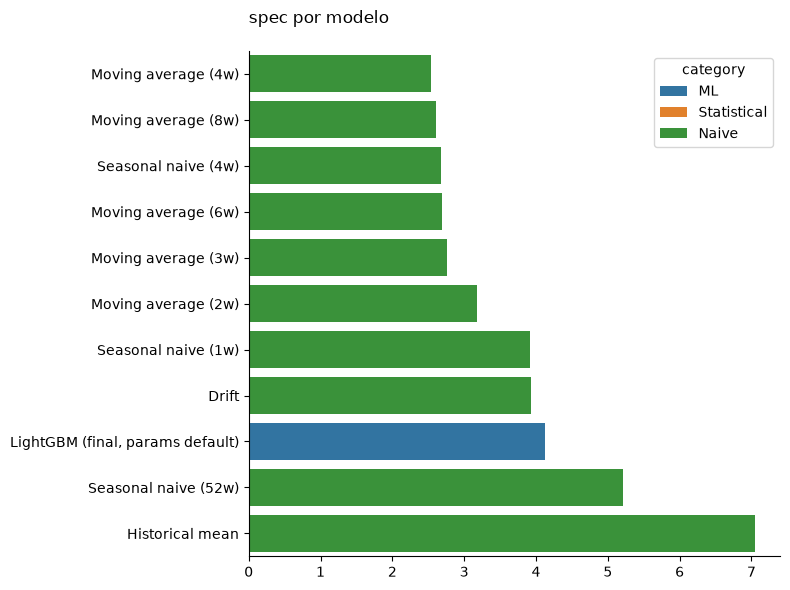

In [39]:
#['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
for col in ['wape', 'wrmsse', 'spec']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

## Explicación modelo

In [40]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(300_000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                            feature  mean_abs_shap
9                    avg_sell_price       1.382135
12                    price_vs_mean       0.249638
22                     price_vs_max       0.201568
64    rolling_max_lag1_window_size4       0.198970
0                           item_id       0.150129
..                              ...            ...
84  rolling_min_lag13_window_size13       0.000000
88  rolling_min_lag13_window_size26       0.000000
85  rolling_max_lag13_window_size13       0.000000
93   rolling_min_lag52_window_size4       0.000000
97  rolling_min_lag52_window_size13       0.000000

[99 rows x 2 columns]


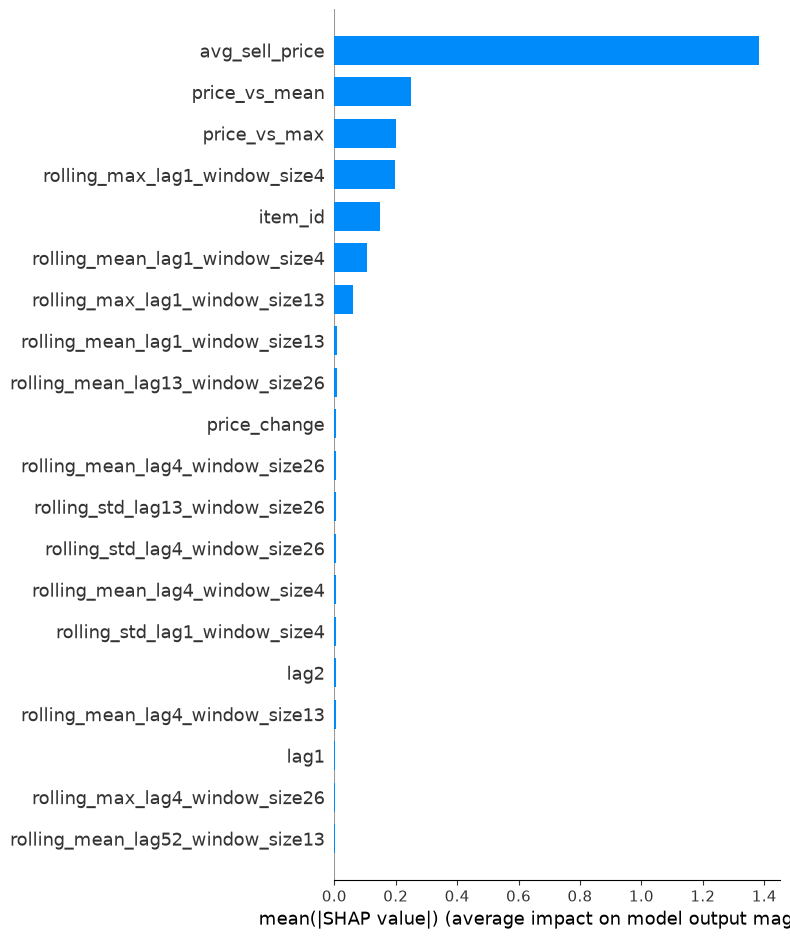

In [41]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

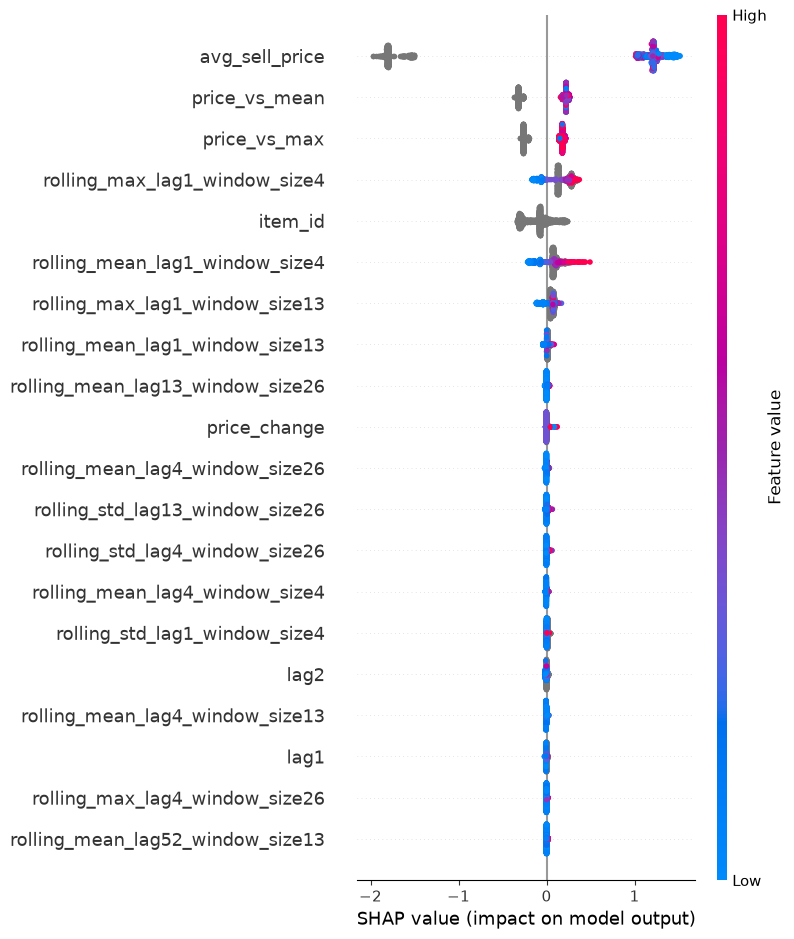

In [42]:
shap.summary_plot(shap_values, X_shap)

# Predicciones

In [43]:
from src.evaluation import analizar_prediccion, plot_forecast, explain_prediction

In [44]:
metrics_test_final, df_pred = build_predictions_report(artifact['train'], artifact['test'], y_test, model.predict(X_test), target_col=artifact['target'])

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

Test WAPE: 70.17%
Test WRMSSE: 0.9827


In [45]:
from src.evaluation.metrics import build_series_metrics

df_metrics = build_series_metrics(artifact['train'], df_pred, target_col=artifact['target'], weight_level=["date"])

df_metrics.to_clipboard()

/home/njimenez/Workspace/magister/forecast-tfm/notebooks/../src/evaluation/metrics.py:12: RuntimeWarning: invalid value encountered in scalar divide
  return np.abs(y_true - y_pred).sum() / np.abs(y_true).sum()
/home/njimenez/Workspace/magister/forecast-tfm/notebooks/../src/evaluation/metrics.py:17: RuntimeWarning: invalid value encountered in scalar divide
  return (y_pred - y_true).sum() / np.abs(y_true).sum()


In [46]:
df_metrics.head(5)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
HOBBIES_1_HOBBIES_HOBBIES_1_158_WI_3_WI,4,4,45.0,42.0,3.0,13.0,1034.099976,0.044399,0.288889,-0.066667,0.377480,0.923077,0.691508,0.838294,2.6250
HOBBIES_1_HOBBIES_HOBBIES_1_354_WI_3_WI,4,4,24.0,25.0,-1.0,9.0,551.520020,0.023680,0.375000,0.041667,0.654687,-0.444444,0.508625,0.742386,1.3750
HOBBIES_1_HOBBIES_HOBBIES_1_099_WI_3_WI,4,4,30.0,31.0,-1.0,9.0,419.399994,0.018007,0.300000,0.033333,0.425103,-0.444444,0.662218,1.170696,1.3750
HOBBIES_1_HOBBIES_HOBBIES_1_330_WI_3_WI,4,4,46.0,55.0,-9.0,19.0,362.479980,0.015563,0.413043,0.195652,0.369526,-1.894737,0.725513,0.940177,2.0625
HOBBIES_1_HOBBIES_HOBBIES_1_204_WI_3_WI,4,4,37.0,24.0,13.0,15.0,359.640015,0.015441,0.405405,-0.351351,0.444073,3.466667,1.341050,1.347656,10.3125


In [47]:
df_metrics.nsmallest(5,'wrmsse')

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
HOBBIES_1_HOBBIES_HOBBIES_1_257_WI_3_WI,4,1,2.0,2.0,0.0,0.0,33.520000,0.001439,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HOBBIES_1_HOBBIES_HOBBIES_1_184_WI_3_WI,4,1,2.0,2.0,0.0,0.0,25.360001,0.001089,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HOBBIES_1_HOBBIES_HOBBIES_1_351_WI_3_WI,4,1,2.0,2.0,0.0,0.0,11.520000,0.000495,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HOBBIES_1_HOBBIES_HOBBIES_1_245_WI_3_WI,4,1,2.0,2.0,0.0,0.0,9.940000,0.000427,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HOBBIES_1_HOBBIES_HOBBIES_1_003_WI_3_WI,4,0,0.0,0.0,0.0,0.0,0.000000,0.000000,NaN,NaN,0.0,0.0,0.0,0.0,0.0


In [48]:
df_metrics.nsmallest(5,'wrmsse')

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
HOBBIES_1_HOBBIES_HOBBIES_1_257_WI_3_WI,4,1,2.0,2.0,0.0,0.0,33.520000,0.001439,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HOBBIES_1_HOBBIES_HOBBIES_1_184_WI_3_WI,4,1,2.0,2.0,0.0,0.0,25.360001,0.001089,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HOBBIES_1_HOBBIES_HOBBIES_1_351_WI_3_WI,4,1,2.0,2.0,0.0,0.0,11.520000,0.000495,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HOBBIES_1_HOBBIES_HOBBIES_1_245_WI_3_WI,4,1,2.0,2.0,0.0,0.0,9.940000,0.000427,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HOBBIES_1_HOBBIES_HOBBIES_1_003_WI_3_WI,4,0,0.0,0.0,0.0,0.0,0.000000,0.000000,NaN,NaN,0.0,0.0,0.0,0.0,0.0


In [53]:
df_metrics.nlargest(5,'sales')

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
HOBBIES_1_HOBBIES_HOBBIES_1_048_WI_3_WI,4,4,157.0,76.0,81.0,107.0,75.360001,0.003236,0.681529,-0.515924,1.046497,3.028037,2.059249,2.108529,69.9375
HOBBIES_1_HOBBIES_HOBBIES_1_032_WI_3_WI,4,4,141.0,53.0,88.0,98.0,80.370003,0.003451,0.695035,-0.624113,1.020546,3.591837,2.231528,2.196101,89.4375
HOBBIES_1_HOBBIES_HOBBIES_1_404_WI_3_WI,4,4,137.0,75.0,62.0,62.0,65.760002,0.002823,0.452555,-0.452555,0.621741,4.000000,1.381827,1.434790,46.5000
HOBBIES_1_HOBBIES_HOBBIES_1_244_WI_3_WI,4,4,93.0,67.0,26.0,42.0,44.639999,0.001917,0.451613,-0.279570,0.537651,2.476190,0.739118,0.870636,24.5625
HOBBIES_1_HOBBIES_HOBBIES_1_261_WI_3_WI,4,4,93.0,67.0,26.0,26.0,44.639999,0.001917,0.279570,-0.279570,0.329742,4.000000,0.555740,0.691982,11.2500


In [49]:
CASES = ['HOUSEHOLD_1_HOUSEHOLD_TX_3_TX', 'HOBBIES_1_HOBBIES_WI_1_WI','HOUSEHOLD_2_HOUSEHOLD_CA_2_CA']

df_metrics.to_clipboard(decimal=",", sep="\t")

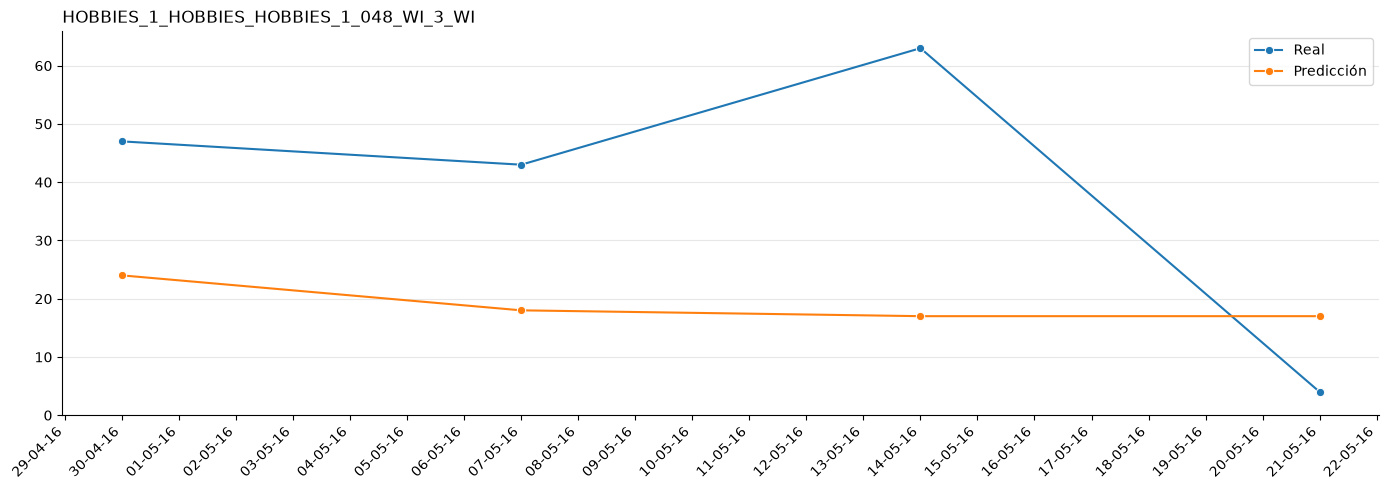

################################################## Date: 2016-04-30 00:00:00 ##################################################


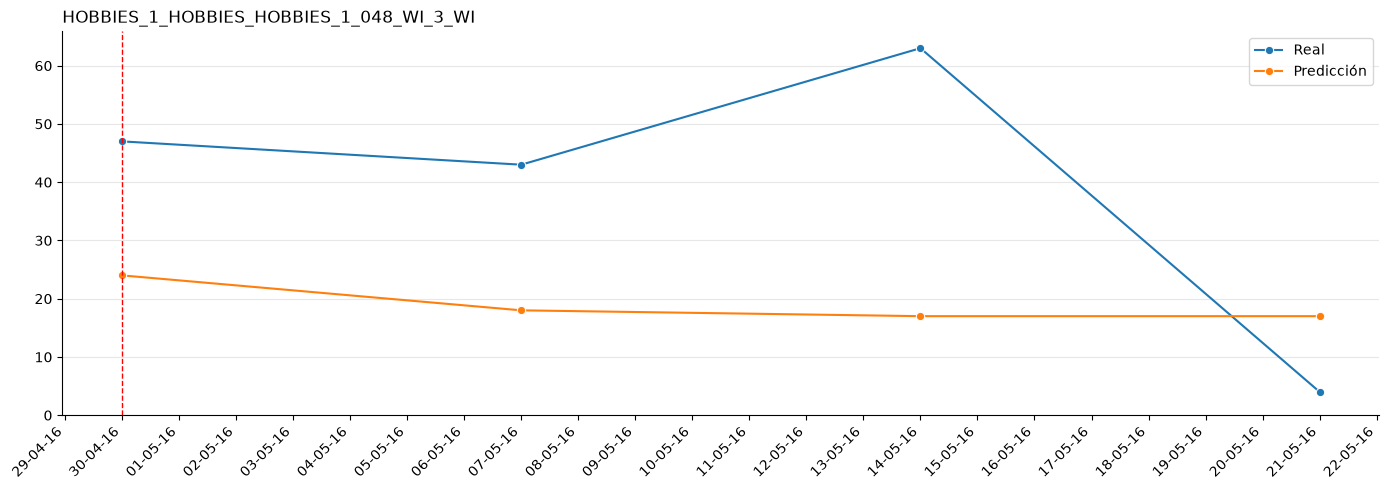

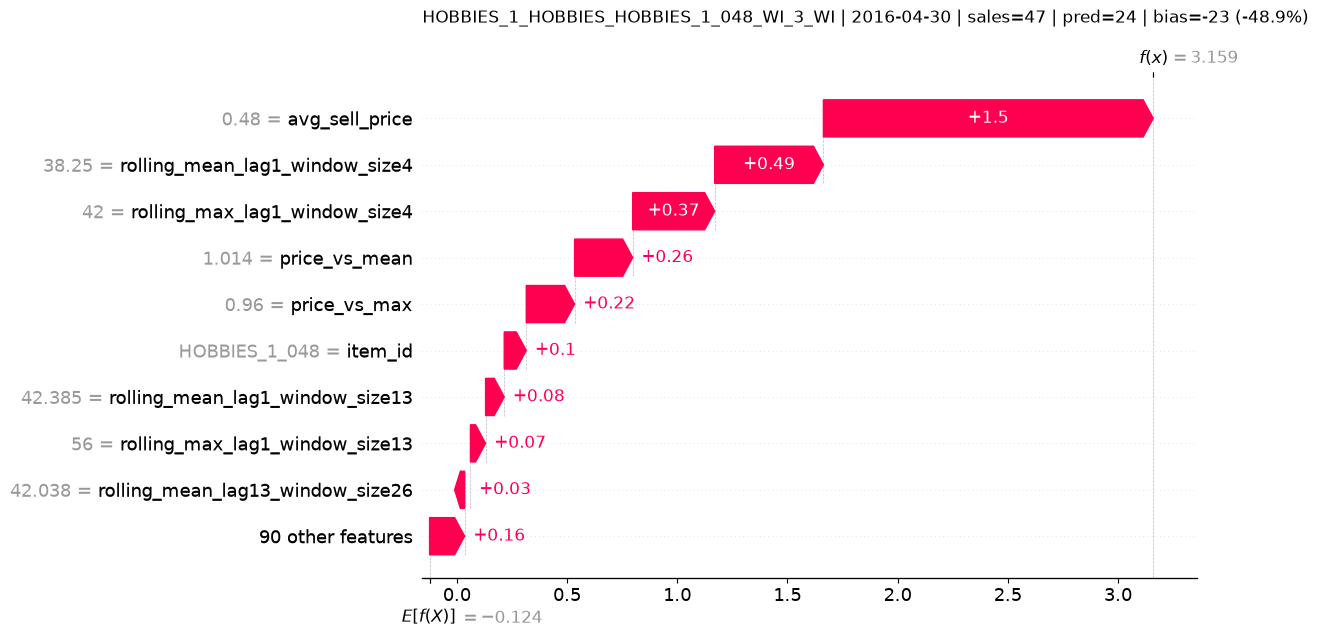

################################################## Date: 2016-05-07 00:00:00 ##################################################


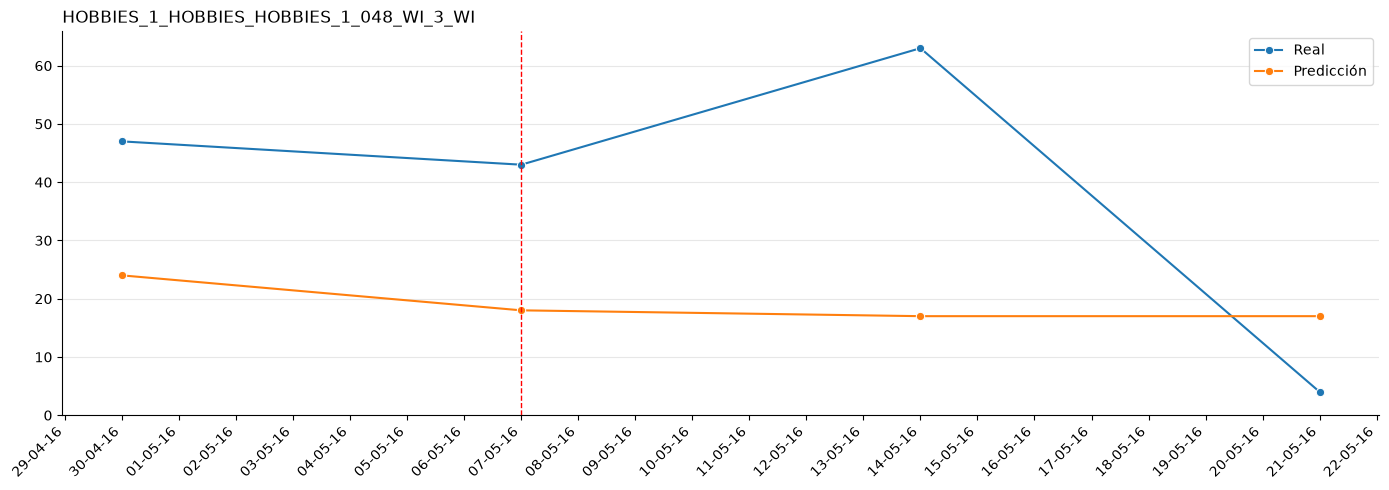

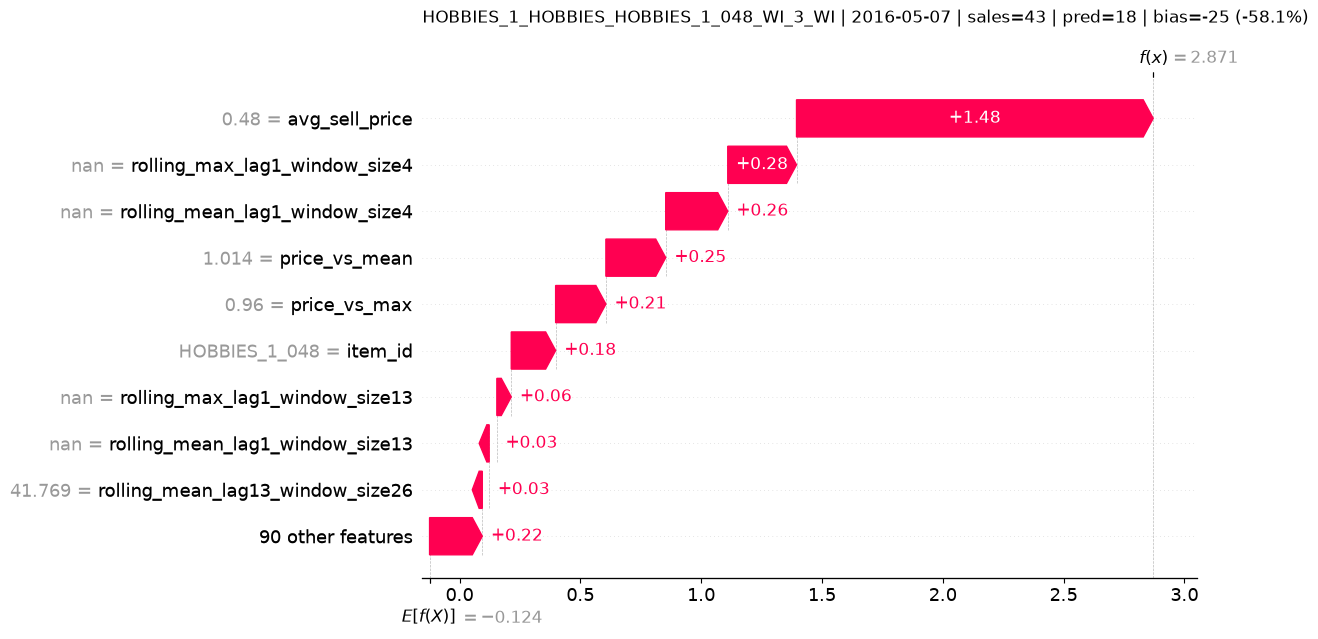

################################################## Date: 2016-05-14 00:00:00 ##################################################


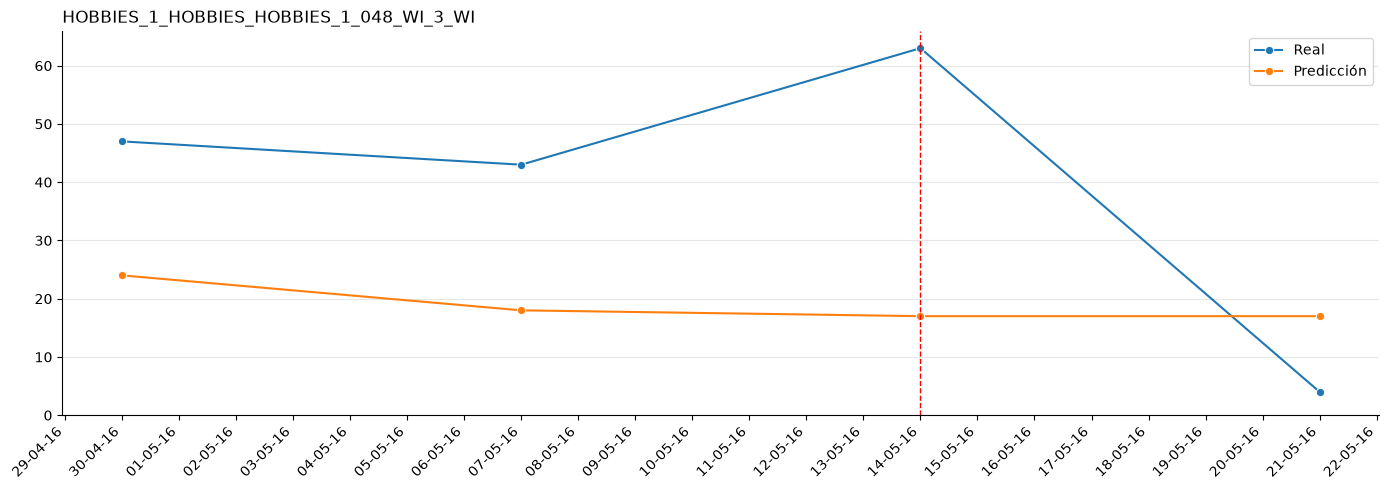

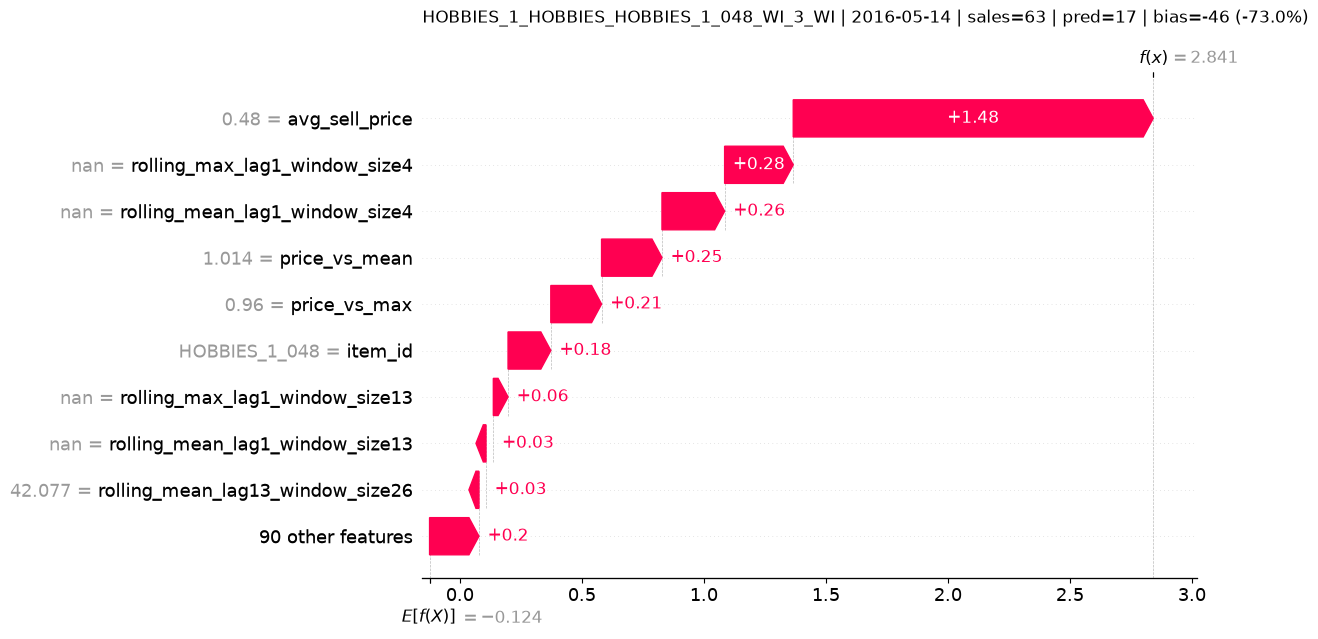

################################################## Date: 2016-05-21 00:00:00 ##################################################


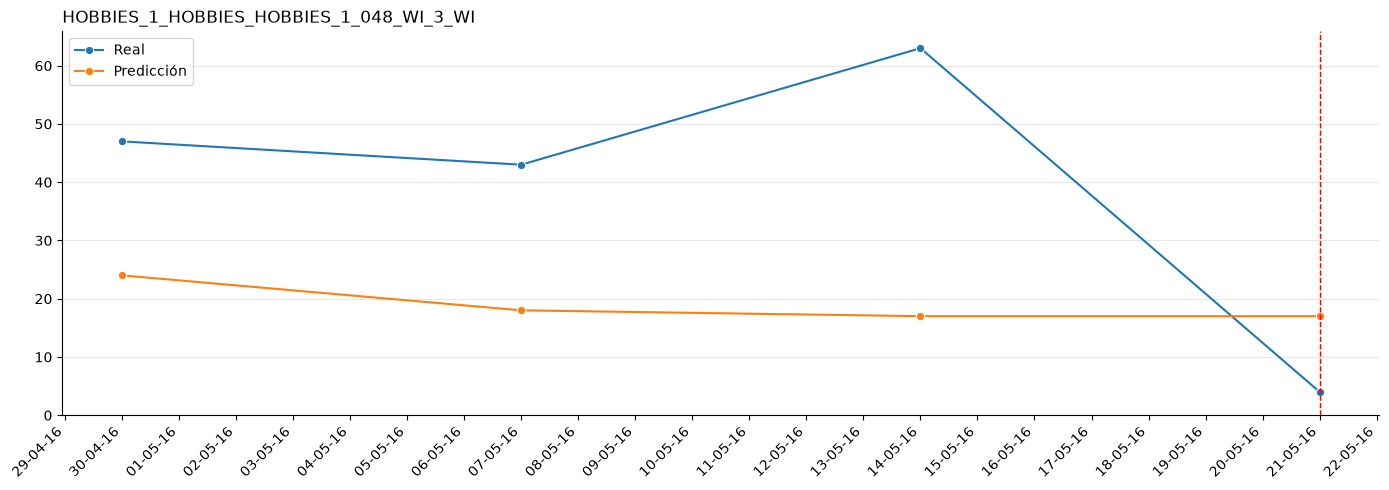

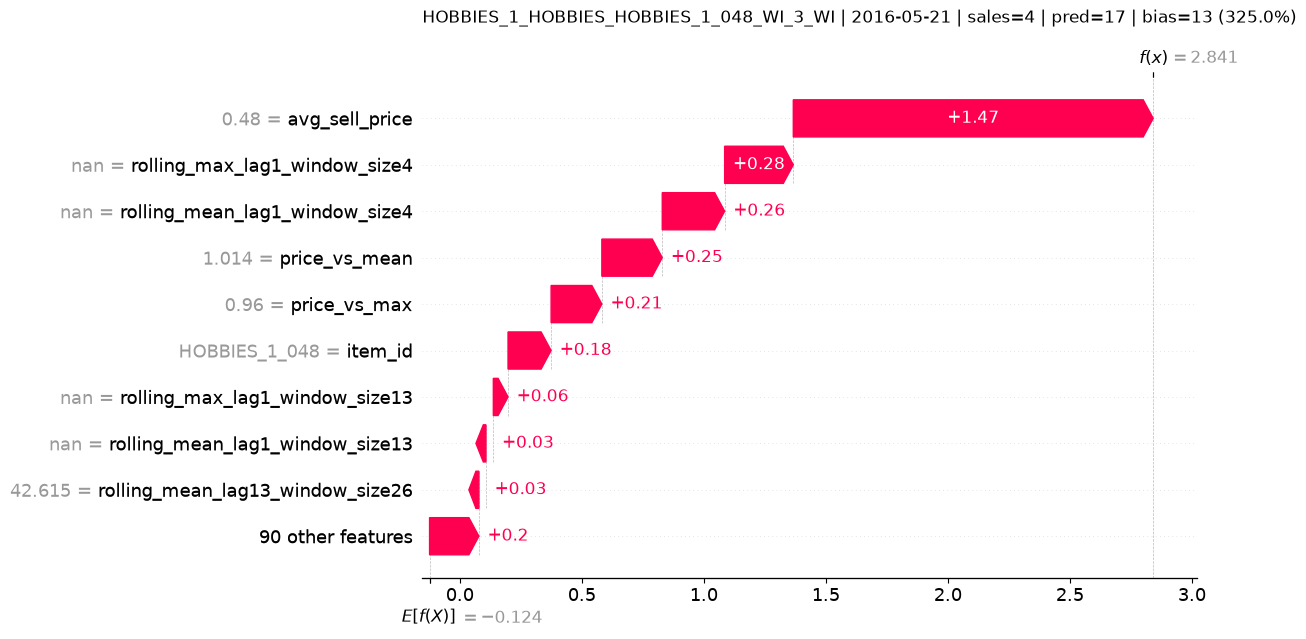

################################################## Date: 2016-05-14 00:00:00 ##################################################


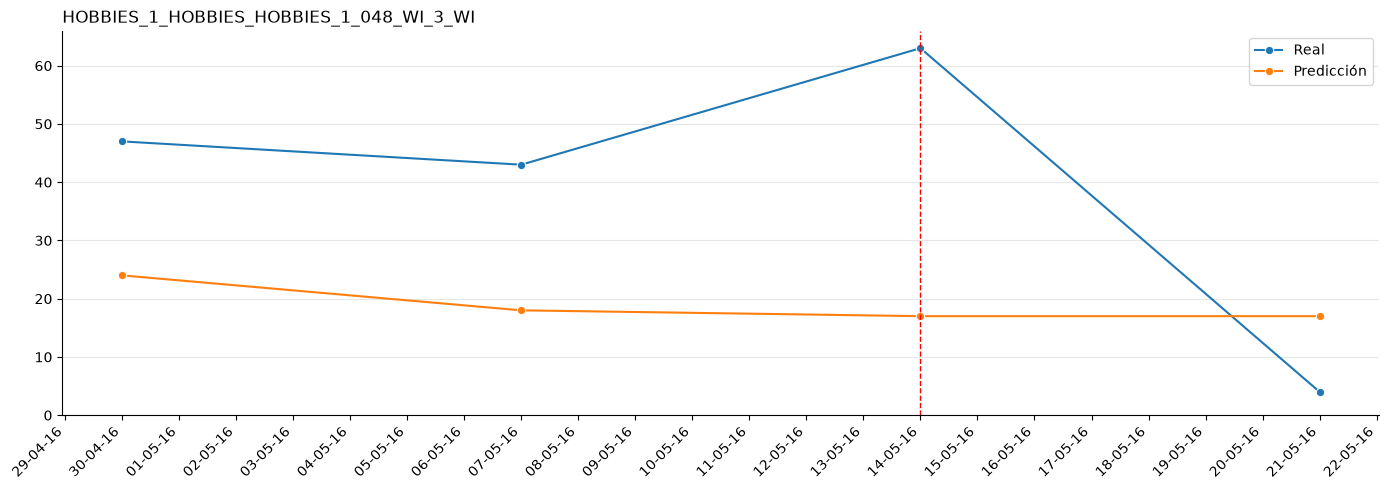

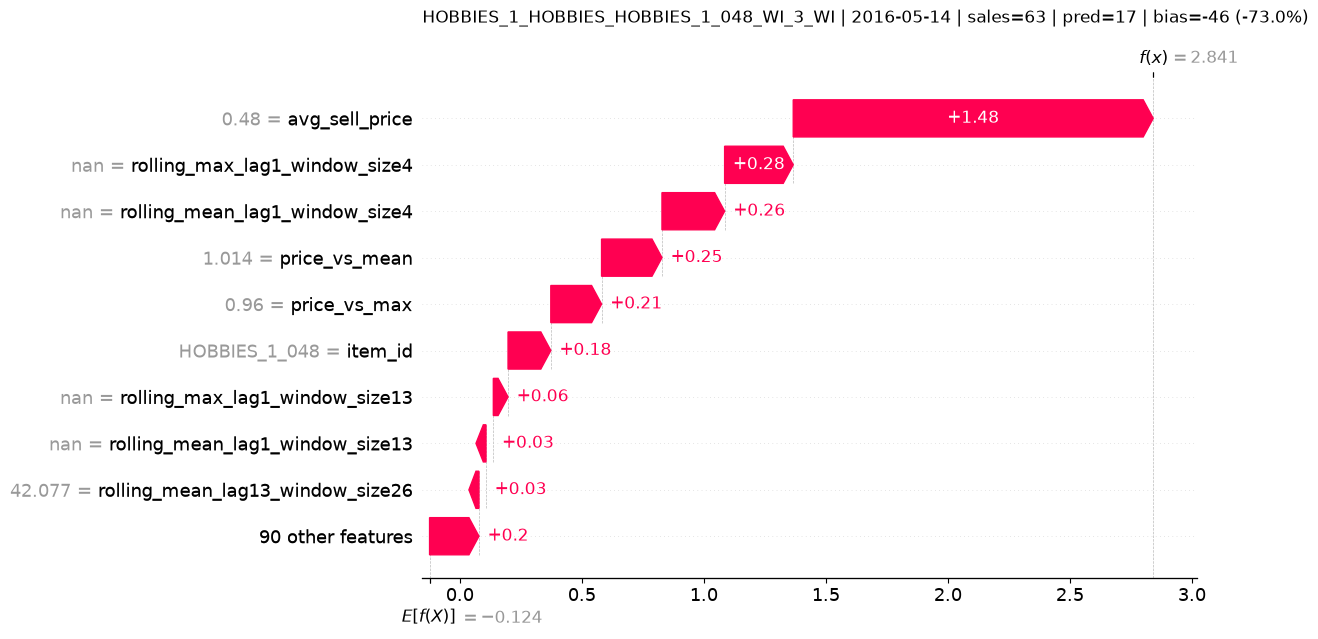

################################################## Date: 2016-05-07 00:00:00 ##################################################


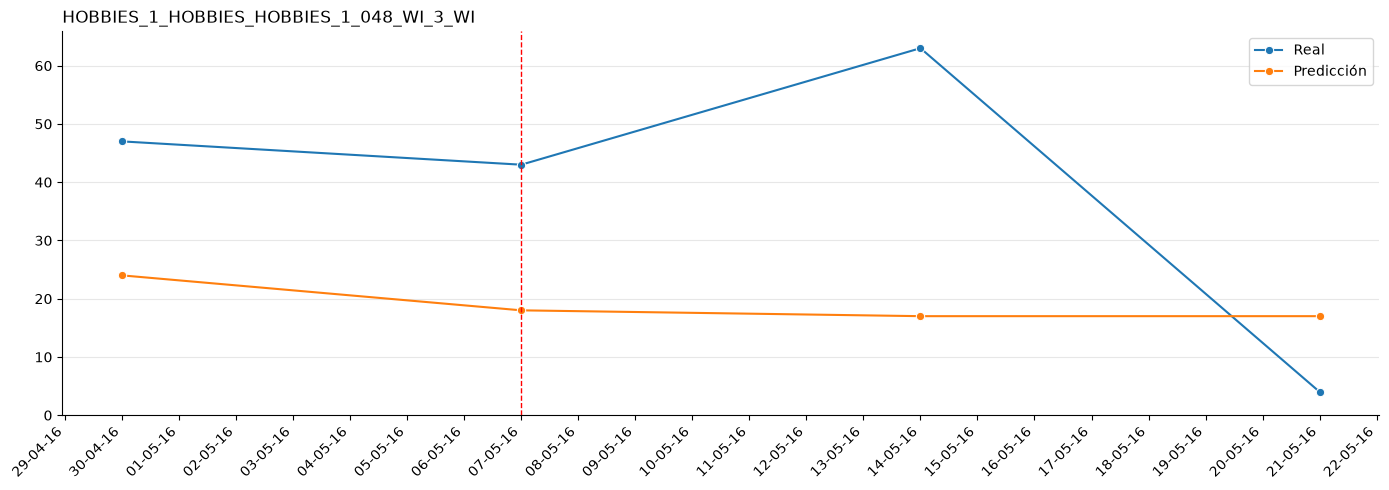

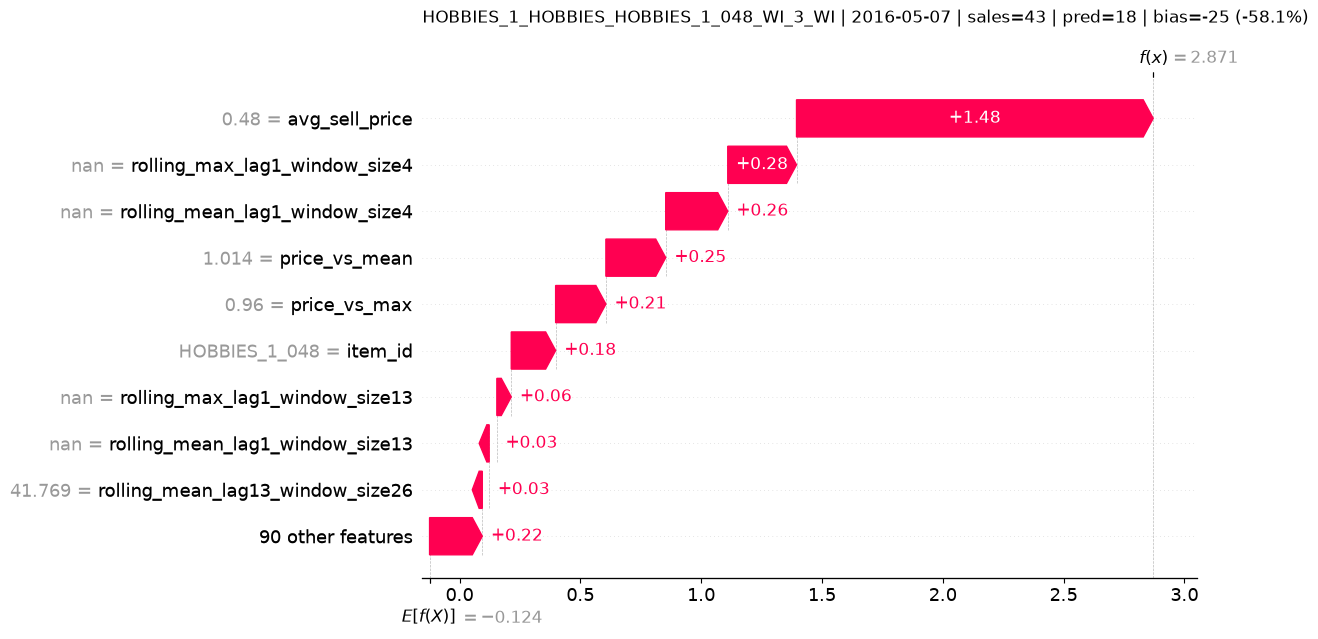

In [54]:
AGG_ID = 'HOBBIES_1_HOBBIES_HOBBIES_1_048_WI_3_WI'

top_best_dates = df_pred.query(f'series_id == "{AGG_ID}"').nsmallest(3, 'wape')['date']
top_error_dates = df_pred.query(f'series_id == "{AGG_ID}"').nlargest(3, 'wape')['date']

plot_forecast(df_pred, 'sales', series_id=AGG_ID)

for i in top_best_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=AGG_ID, explainer=explainer, date=i)

for i in top_error_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=AGG_ID, explainer=explainer, date=i)